## Spectral analysis during ITI phase

### Prepare environment

In [14]:
import os
import re
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy.stats import friedmanchisquare, wilcoxon
from scipy.signal import iirnotch, filtfilt, lfilter
from spectral_connectivity import Multitaper, Connectivity
from spectral_utils import *

warnings.filterwarnings('ignore')
%matplotlib inline

### Set variables

In [15]:
main_path = 'PreProcessedData'
colors = sns.color_palette('Spectral', 14)
color = colors[1]
vmin=0
vmax=.95

### Get data

In [16]:
times, freqs, power = load_arrays(
    main_path, 
    'iti_times.npy', 
    'iti_freqs.npy', 
    'iti_power.npy'
)

In [17]:
ripple_data = pd.read_csv(os.path.join(main_path, 'cg_analysis_ripple_library.csv'), index_col=False)

In [18]:
ripple_numbers = np.load(os.path.join(main_path, 'iti_ripple_numbers.npy'))
tetrodes = np.load(os.path.join(main_path, 'tetrode_numbers.npy'), allow_pickle=True)

### Z-score power
Uses the mean and std withn trial and tetrode (for each trace)

In [19]:
power_zscored = zscore_4d_power(power)

### Remove outliers

Percentage of data points replaced as outliers: 0.67%


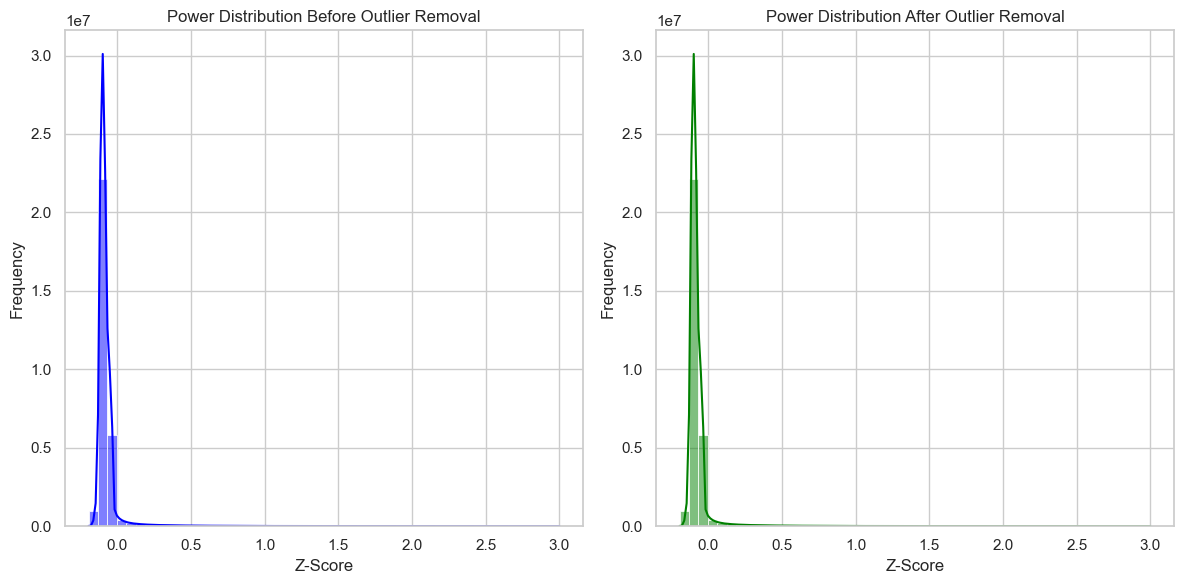

In [21]:
power_processed = remove_outliers_zscored(power_zscored.copy(), z_threshold=3)

### Get average, std and median z-scored power 

In [22]:
mean_ppower, std_ppower, median_ppower = average_power(power_processed)  

### Plot average PSD 
Consider that power data was collected between -0.5 and 1 secs in relation to SWR onset.
However we are only interested in showing between -0.5 sec and 0.5 sec. 

In [23]:
# Create x-ticks labels
x_tick_labels = times[0:11]-0.5

In [24]:
# Check max and min average z-scored power values to adjust vmin and vmax
print(mean_ppower.min(), mean_ppower.max())

-0.09692284985597382 1.0745888408976718


[ 0  1  2  3  4  5  6  7  8  9 10]
4.5
Filtered Frequency bins: [ 0.          2.89351852  5.78703704  8.68055556 11.57407407 14.46759259
 17.36111111 20.25462963 23.14814815 26.04166667 28.93518519 31.8287037
 34.72222222 37.61574074 40.50925926 43.40277778 46.2962963  49.18981481
 52.08333333 54.97685185 57.87037037 60.76388889]
Time bins: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


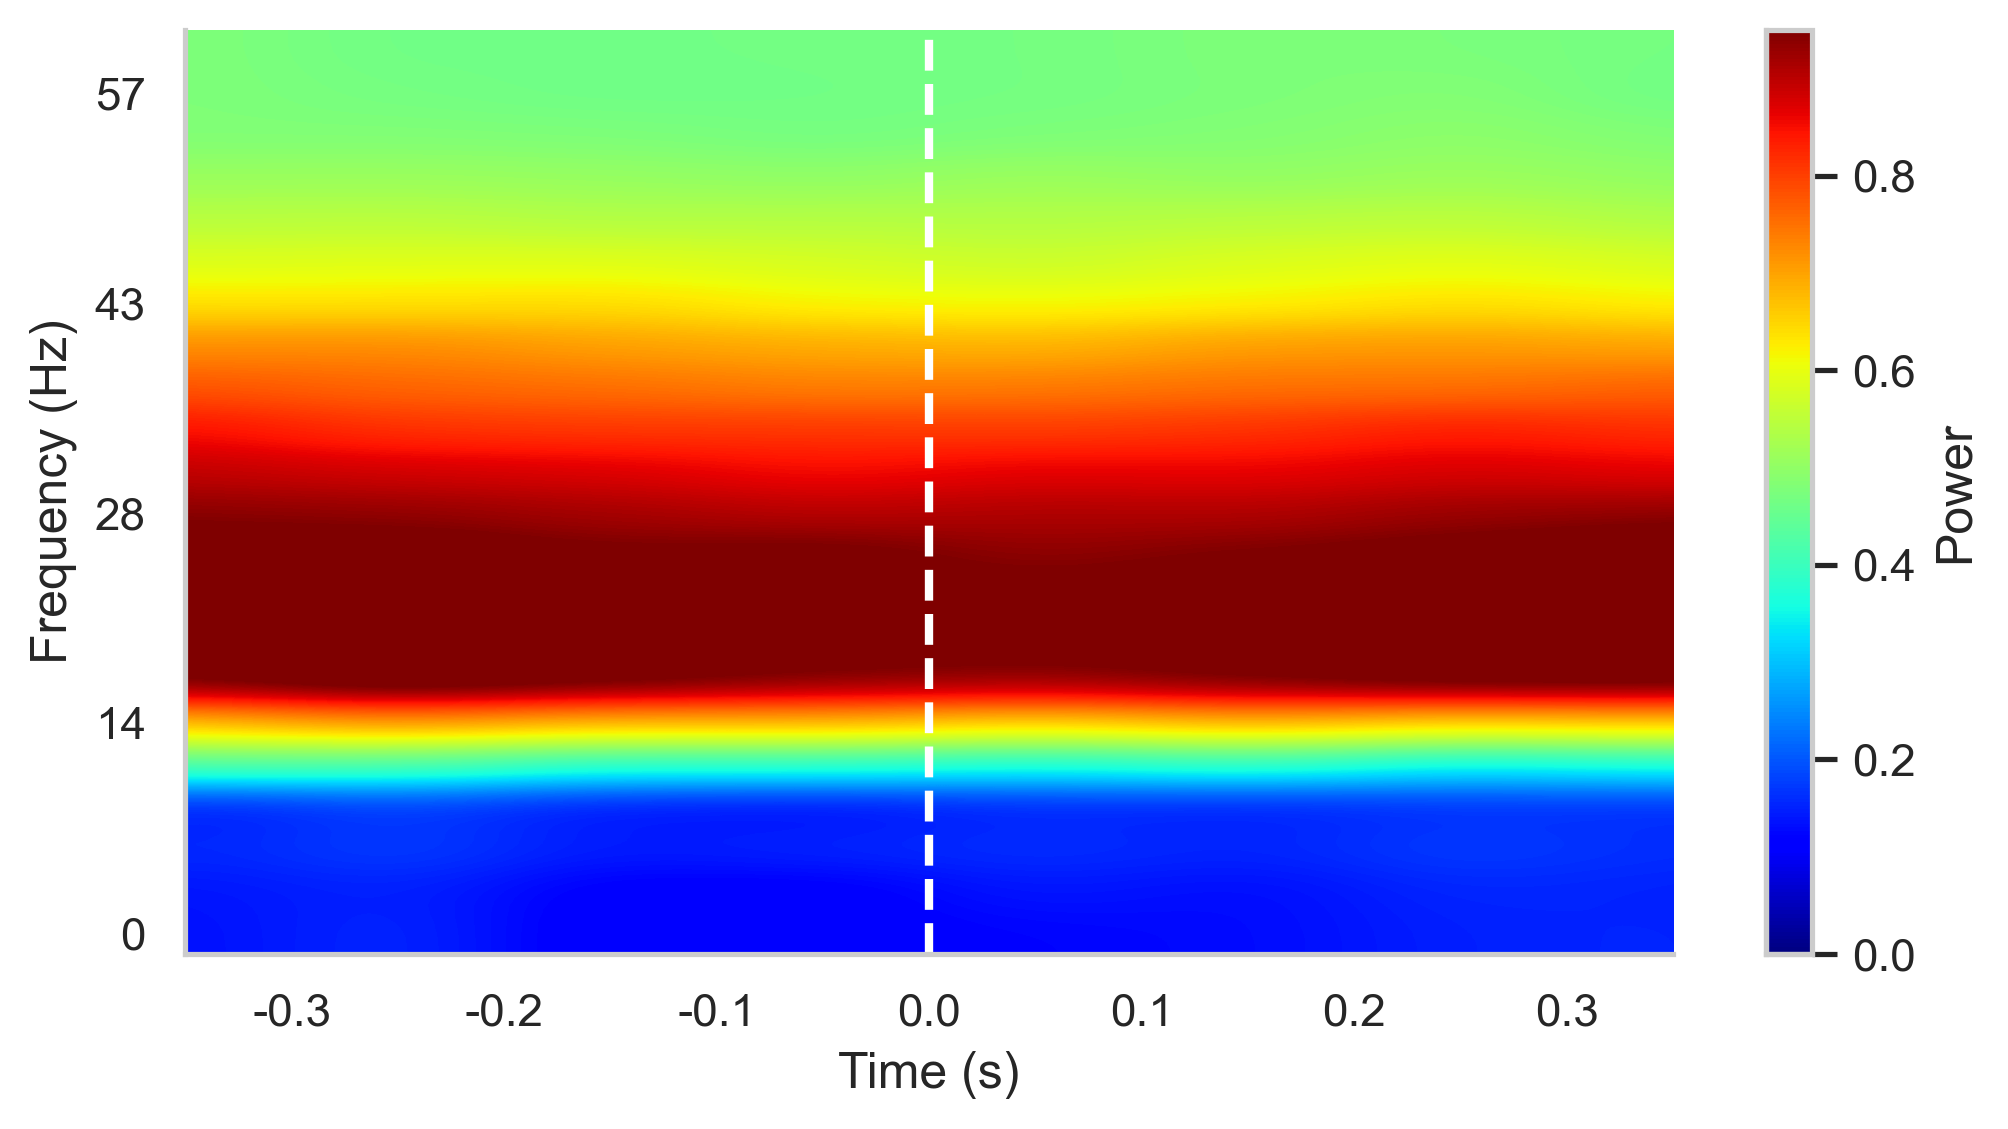

In [32]:
plot_psd_band(
    times, 
    freqs, 
    mean_ppower, 
    ylim = (0,63), 
    x_tick_labels = x_tick_labels, 
    vmin = vmin, 
    vmax = vmax
)
plt.xlim([1,8])
# Define the directory and filename
directory = '/Users/bgoncalves/Desktop/Sofia - PhD/SVG Figures'
filename = 'F4_A.svg'

# Save the figure as an SVG file
fig = plt.gcf()  # Get the current figure
fig.savefig(os.path.join(directory, filename), format='svg')

plt.show()

### Plot median PSD

In [26]:
# Check max and min median z-scored power values to adjust vmin and vmax
print(mean_ppower.min(), mean_ppower.max())

-0.09692284985597382 1.0745888408976718


[ 0  1  2  3  4  5  6  7  8  9 10]
4.5
Filtered Frequency bins: [ 0.          2.89351852  5.78703704  8.68055556 11.57407407 14.46759259
 17.36111111 20.25462963 23.14814815 26.04166667 28.93518519 31.8287037
 34.72222222 37.61574074 40.50925926 43.40277778 46.2962963  49.18981481
 52.08333333 54.97685185 57.87037037 60.76388889]
Time bins: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


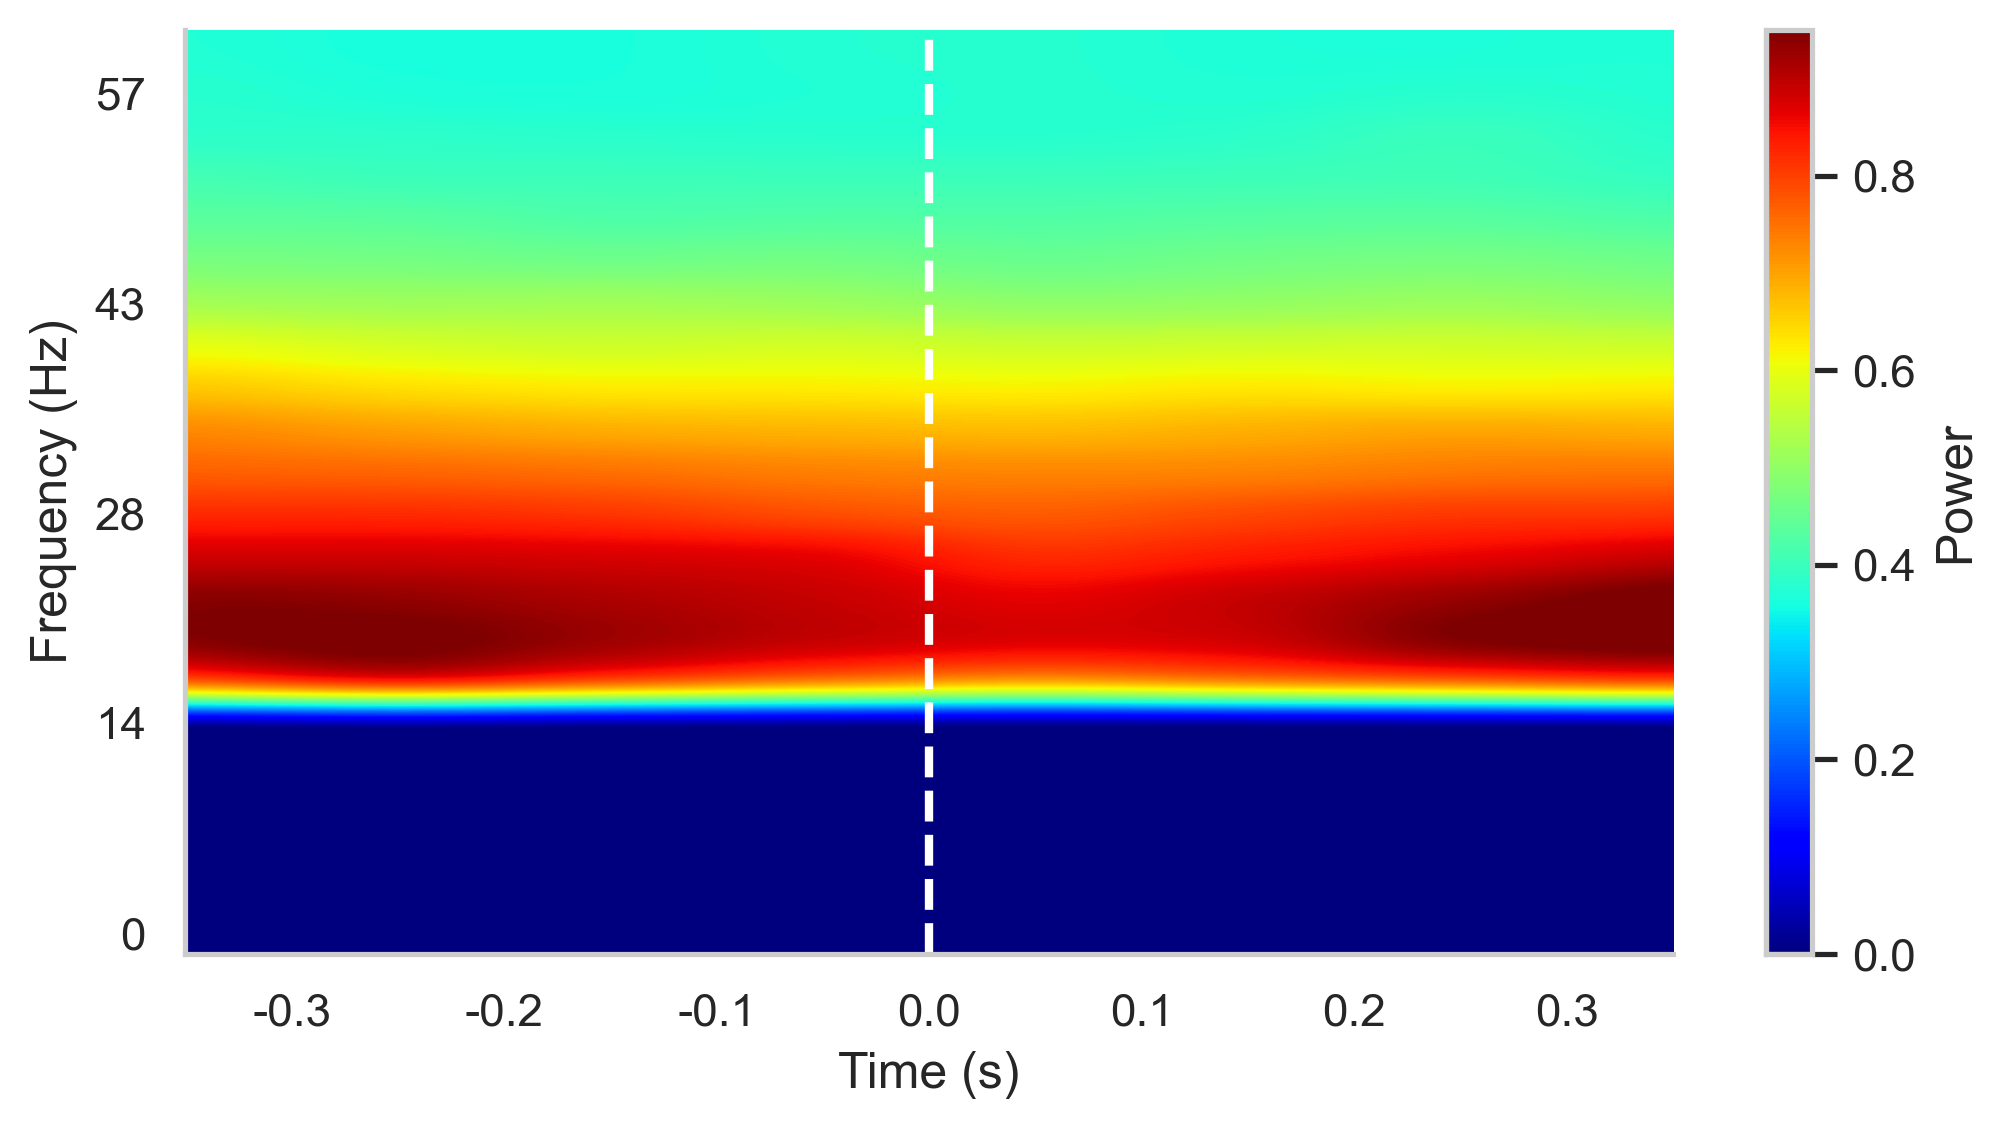

In [31]:
plot_psd_band(
   times, 
    freqs, 
    median_ppower, 
    ylim=(0,63), 
    x_tick_labels=x_tick_labels,
    vmin=vmin, 
    vmax=vmax
)

plt.xlim([1,8])
# Define the directory and filename
directory = '/Users/bgoncalves/Desktop/Sofia - PhD/SVG Figures'
filename = 'F4_B.svg'

# Save the figure as an SVG file
fig = plt.gcf()  # Get the current figure
fig.savefig(os.path.join(directory, filename), format='svg')

### Plot median and average z-scored power values across time bins 

In [54]:
# Convert to a dataframe with long format 
# Assumes the reshaping made to calculate power maintains order of  ripples and tetrodes  - Ask chatgpt

ppower_df = convert_to_long_format(
    power_processed, 
    time_bin_values = times-.5, 
    frequency_bin_values= freqs, 
    ripple_labels = ripple_numbers, 
    tetrode_labels = tetrodes
)

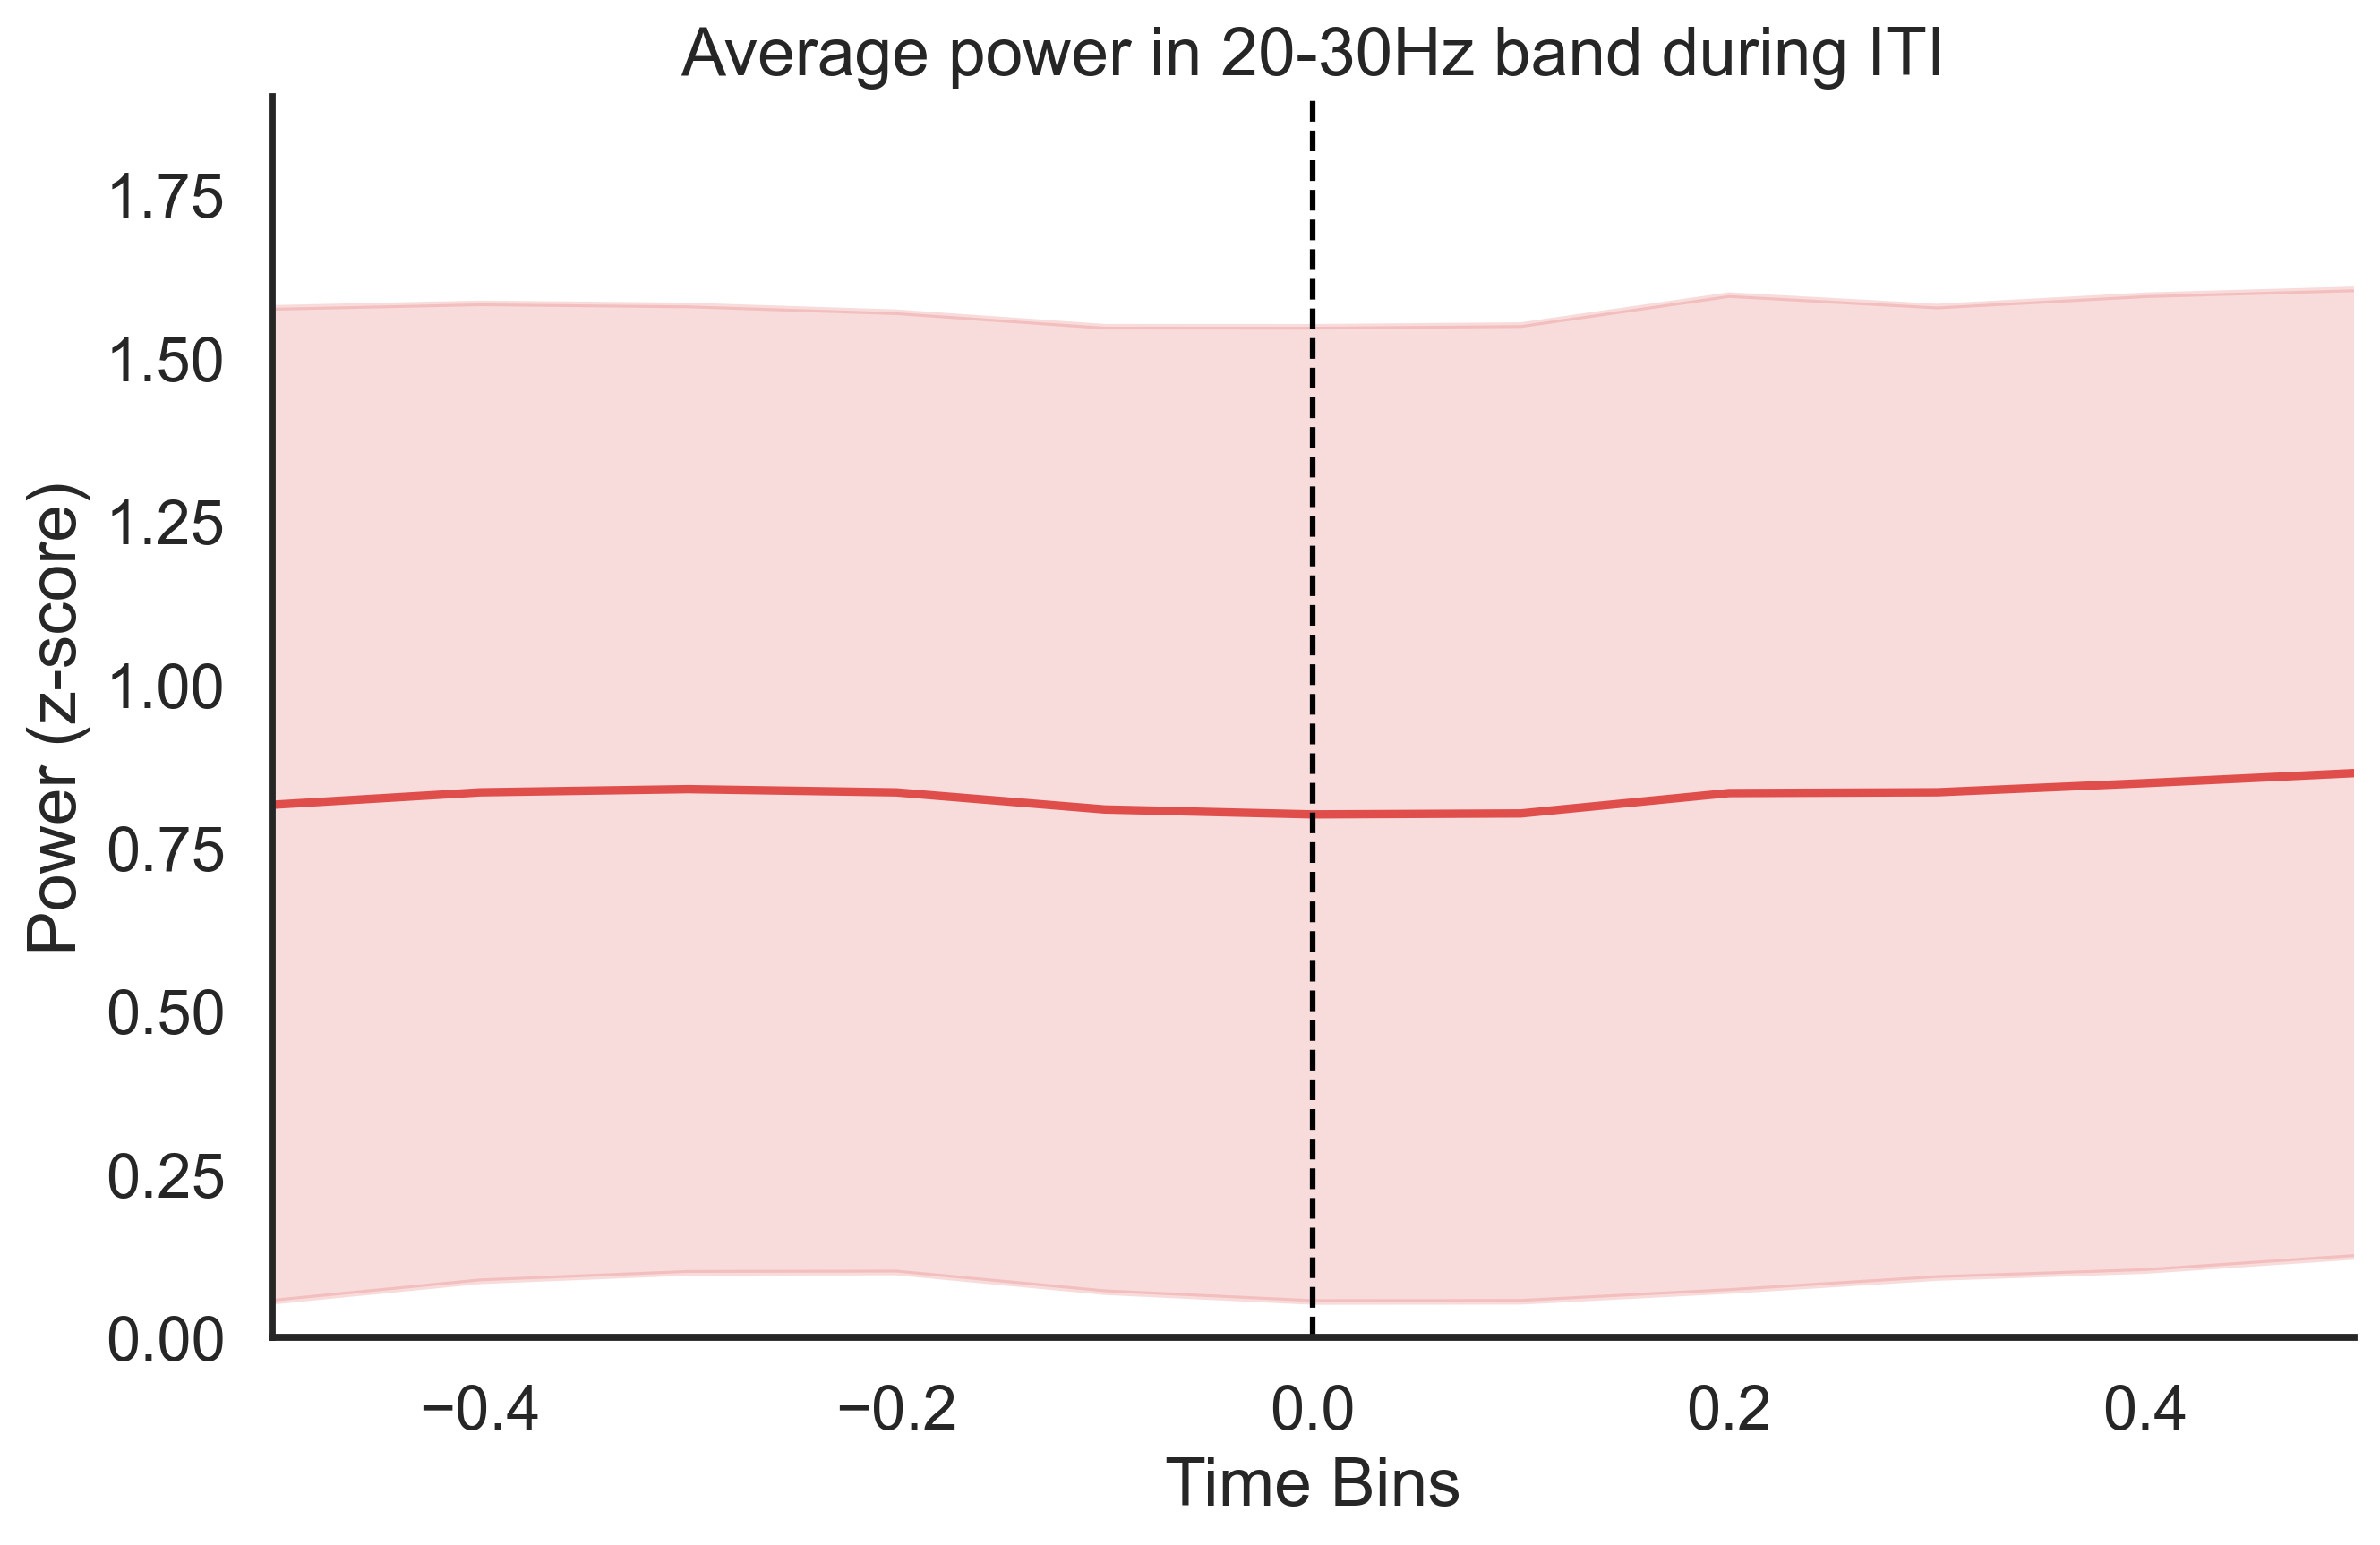

In [65]:
plot_average_power(
    ppower_df, 
    band=(20,30),
    title='Average power in 20-30Hz band during ITI', 
    color=color, 
    ylim=(0, 1.9), 
    xlim=(-0.5,0.5)
)

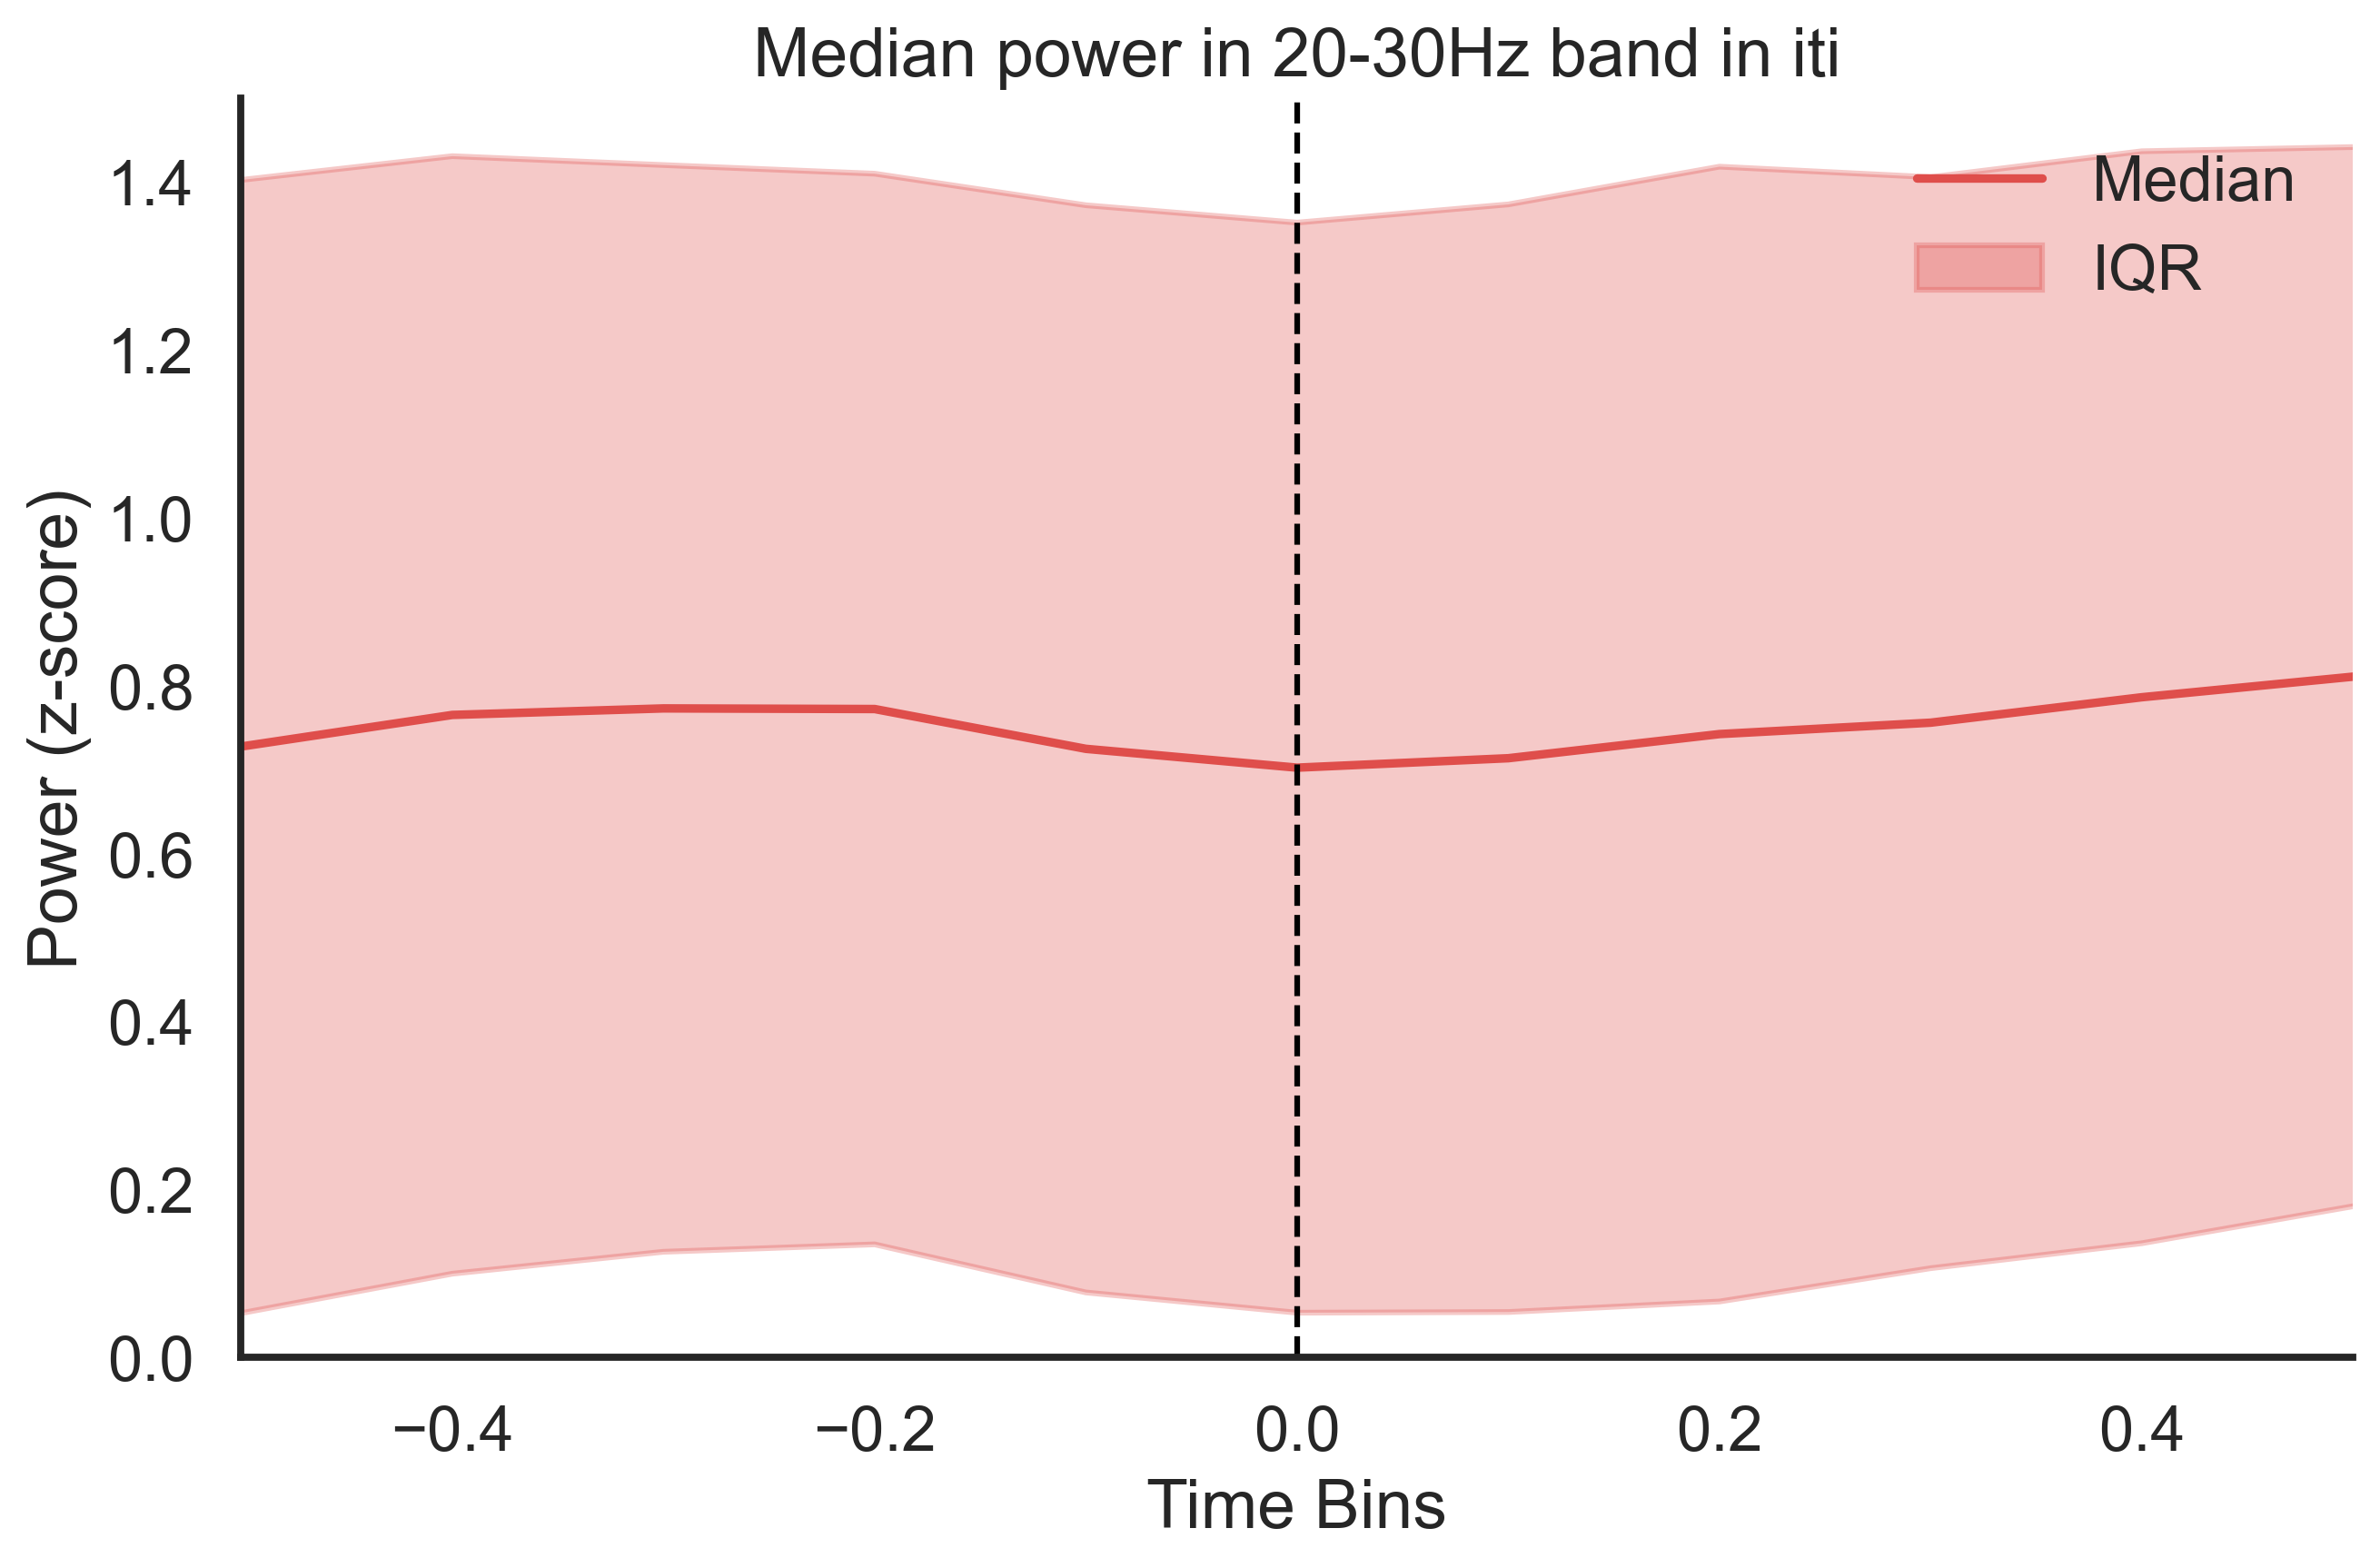

In [71]:
plot_median_power(
    ppower_df, 
    band=(20,30),
    title='Median power in 20-30Hz band in iti', 
    color=color, 
    ylim=(0,1.5), 
    xlim=(-0.5,0.5)
)

### Pairwise differences
From the information above, it appears that there is a potentially relevant z-scored power change in the first two timebins following ripple start. We'll compare time bin 0 and 0.1 to the previous time bin before ripple occurrence

In [ ]:
# Label timepoints of interest to compare z-scored power pairwise differences
ppower_df.loc[np.round(ppower_df.time_bins, 1) ==-0.1, 'time_points']= '1' 
ppower_df.loc[np.round(ppower_df.time_bins,1) == 0, 'time_points']= '2' 
ppower_df.loc[np.round(ppower_df.time_bins,1) == 0.1, 'time_points']= '3'    

In [ ]:
# Confirm labelling
ppower_df[['time_bins', 'time_points']].dropna().drop_duplicates()

In [ ]:
# Plot pairwise differences between baseline (timepoint 1) and first time bin of interest
# For band of interest(43-47Hz)

changes, df_tp1, df_tp2 = analyze_specific_power_change(
    ppower_df, 
    ('1','2'), 
    band=(43,47), 
    color=phase_palette[1], 
    bins=(-2, 2, 0.1), 
    xlim=(-2,2)
)